## **Plantilla**

In [ ]:
import pandas as pd

ruta = "https://raw.githubusercontent.com/VillaltaE/netflix_churn/refs/heads/main/netflix_customer_churn.csv"
df = pd.read_csv(ruta)

model_cols = [
    "subscription_type",
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day",
    "payment_method"
]

X = df[model_cols]
y = df["churned"]

X.head(), y.value_counts(normalize=True)


(  subscription_type  watch_hours  last_login_days  monthly_fee  \
 0             Basic        14.73               29         8.99   
 1          Standard         0.70               19        13.99   
 2          Standard        16.32               10        13.99   
 3           Premium         4.51               12        17.99   
 4          Standard         1.89               13        13.99   
 
    number_of_profiles  avg_watch_time_per_day payment_method  
 0                   1                    0.49      Gift Card  
 1                   5                    0.03      Gift Card  
 2                   2                    1.48         Crypto  
 3                   2                    0.35         Crypto  
 4                   2                    0.13         Crypto  ,
 churned
 1    0.503
 0    0.497
 Name: proportion, dtype: float64)

## **Importar lo necesario**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier as RandomForest
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,accuracy_score,roc_curve
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt



## **Definir columnas por tipo**



In [ ]:
categorical_cols = ["subscription_type","payment_method"]
numeric_cols = [
    "watch_hours",
    "last_login_days",
    "monthly_fee",
    "number_of_profiles",
    "avg_watch_time_per_day"
]


### **Codificación de las variables**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer

In [ ]:
one_hot = make_column_transformer((OneHotEncoder(handle_unknown="ignore"), 
                                  ['subscription_type','payment_method']),
                                  remainder='passthrough',
                                  sparse_threshold=0,
                                  force_int_remainder_cols=False)

In [ ]:
one_hot

ColumnTransformer(force_int_remainder_cols=False, remainder='passthrough',
                  sparse_threshold=0,
                  transformers=[('onehotencoder',
                                 OneHotEncoder(handle_unknown='ignore'),
                                 ['subscription_type', 'payment_method'])])

In [ ]:
X = one_hot.fit_transform(X)

In [ ]:
one_hot.get_feature_names_out(model_cols)

array(['onehotencoder__subscription_type_Basic',
       'onehotencoder__subscription_type_Premium',
       'onehotencoder__subscription_type_Standard',
       'onehotencoder__payment_method_Credit Card',
       'onehotencoder__payment_method_Crypto',
       'onehotencoder__payment_method_Debit Card',
       'onehotencoder__payment_method_Gift Card',
       'onehotencoder__payment_method_PayPal', 'remainder__watch_hours',
       'remainder__last_login_days', 'remainder__monthly_fee',
       'remainder__number_of_profiles',
       'remainder__avg_watch_time_per_day'], dtype=object)

## **Train/Validation/Test split (80/20)**

In [ ]:
X, X_test, y, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X,y, random_state=42, stratify=y)

In [ ]:
X_test.shape, X_test.shape

((1000, 13), (1000, 13))

### **Normalización y estandarización de los datos**

In [ ]:
from sklearn.preprocessing import RobustScaler

In [ ]:
#Importamos RobusScaler para el escalamiento de los datos, ya que es robusto a los datoa atípicos
# y no tiene el supuesto de que los datos tienen una distribución normal

robust_scaler = RobustScaler()

X_train = robust_scaler.fit_transform(X_train)
X_val = robust_scaler.fit_transform(X_val)
X_test = robust_scaler.fit_transform(X_test)



In [ ]:
df_codificado = pd.DataFrame(X_train, columns=one_hot.get_feature_names_out(model_cols))

In [ ]:
df_codificado.head()

,onehotencoder__subscription_type_Basic,onehotencoder__subscription_type_Premium,onehotencoder__subscription_type_Standard,onehotencoder__payment_method_Credit Card,onehotencoder__payment_method_Crypto,onehotencoder__payment_method_Debit Card,onehotencoder__payment_method_Gift Card,onehotencoder__payment_method_PayPal,remainder__watch_hours,remainder__last_login_days,remainder__monthly_fee,remainder__number_of_profiles,remainder__avg_watch_time_per_day
0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.149555,-0.300000,0.444444,-0.5,0.262295
1,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.155094,-0.066667,0.000000,1.0,0.081967
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-0.508803,-0.900000,-0.555556,0.0,0.213115
3,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.431256,-0.733333,0.000000,0.0,0.000000
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.059347,-0.233333,-0.555556,0.0,0.114754


In [ ]:
df_codificado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 13 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   onehotencoder__subscription_type_Basic     3000 non-null   float64
 1   onehotencoder__subscription_type_Premium   3000 non-null   float64
 2   onehotencoder__subscription_type_Standard  3000 non-null   float64
 3   onehotencoder__payment_method_Credit Card  3000 non-null   float64
 4   onehotencoder__payment_method_Crypto       3000 non-null   float64
 5   onehotencoder__payment_method_Debit Card   3000 non-null   float64
 6   onehotencoder__payment_method_Gift Card    3000 non-null   float64
 7   onehotencoder__payment_method_PayPal       3000 non-null   float64
 8   remainder__watch_hours                     3000 non-null   float64
 9   remainder__last_login_days                 3000 non-null   float64
 10  remainder__monthly_fee  

### **Analisis de multicolinealidad entre variables del modelo** 

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
df_vif = df_codificado.copy()
vif_data = pd.DataFrame()
vif_data['feature'] = df_vif.columns

vif_data['VIF'] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [ ]:
vif_data

,feature,VIF
0,onehotencoder__subscription_type_Basic,inf
1,onehotencoder__subscription_type_Premium,inf
2,onehotencoder__subscription_type_Standard,inf
3,onehotencoder__payment_method_Credit Card,inf
4,onehotencoder__payment_method_Crypto,inf
5,onehotencoder__payment_method_Debit Card,inf
6,onehotencoder__payment_method_Gift Card,inf
7,onehotencoder__payment_method_PayPal,inf
8,remainder__watch_hours,1.180053
9,remainder__last_login_days,1.197609


El análisis de multicoliealidad entre las variables muestra valores muy altos en las variables tipo de plan, método de pago y pago por mes. Se entiende que las columnas que hacen referencia a un método de pago se encuentran relacionadas entre sí. Lo mismo podemos decir de las columnas de tipo de plan. 

Habría que investigar con cual variable monthly fee tiene multicolinealidad.

### **Balanceo de datos**

Los datos de entrenamiento no requieren el paso de balanceo dado que las dos clases de churn se encuentran equilibradas.

In [ ]:
df.churned.value_counts(normalize=True)

,proportion
churned,
1,0.503
0,0.497


## **Entrenar**

In [105]:
#Instanciamos el modelo
clf = LogisticRegression(random_state=42, max_iter=1000)

In [106]:
#Entranamos con los datos de entenamiento
clf.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [107]:
#Métrica del modelo de entrenamiento
print(f'La exactidud del modelo de entrenamiento es {clf.score(X_train,y_train)}')

La exactidud del modelo de entrenamiento es 0.907


## **Evaluación de los modelos**

### Reporte de clasificación

In [108]:
y_pred = clf.predict(X_val)
print(classification_report(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.88      0.89       497
           1       0.89      0.90      0.89       503

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



### Matriz de confusión

In [109]:
print(confusion_matrix(y_val, y_pred))

[[439  58]
 [ 52 451]]


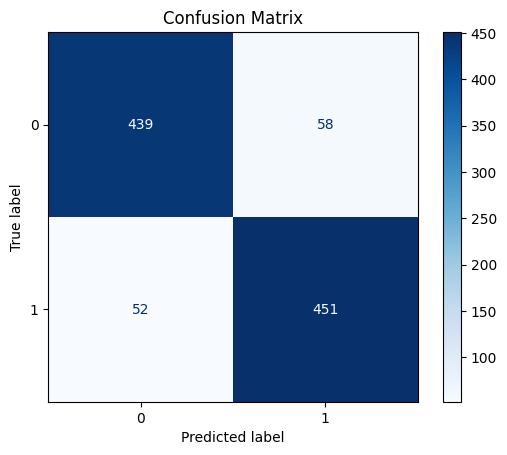

In [110]:
#Gráfico de la matriz de confunción que nos muestra que tan bien está prediciendo
visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_val, y_pred))
visualizacion.plot(cmap='Blues');
plt.title('Confusion Matrix')

plt.show()

### Precisión

In [111]:
print(f'La precisión del modelo con los datos de validación es : {accuracy_score(y_val, y_pred)}')

La precisión del modelo con los datos de validación es : 0.89


### Curva ROC

In [112]:
print(roc_curve(y_val, y_pred))

(array([0.       , 0.1167002, 1.       ]), array([0.        , 0.89662028, 1.        ]), array([inf,  1.,  0.]))


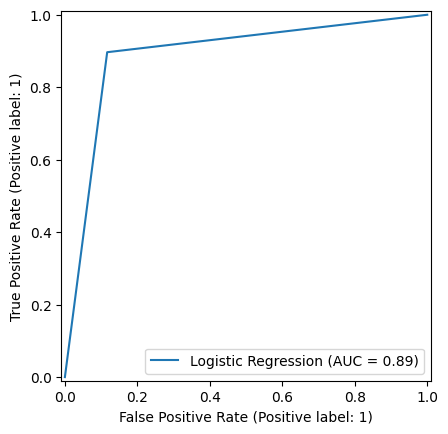

In [113]:
RocCurveDisplay.from_predictions(y_val,y_pred,name='Logistic Regression');

In [114]:
from sklearn.metrics import roc_auc_score

In [115]:
#Gráfico alternativo de la curva ROC
# Generar un predictor sin habilidad
ns_probs = [0 for _ in range(len(y_test))]
# Probabilidades de la regresión logistica
#lr_probs = clf.predict_proba(X_test)
# Probabilidad de solo la clase "1"
#lr_probs = lr_probs[:, 1]
# Calculo de la métrica auc
ns_auc = roc_auc_score(y_val, ns_probs)
lr_auc = roc_auc_score(y_val, y_pred)

#print(ns_auc)
#print(lr_auc)

# Cáculo de la curva roc
ns_fpr, ns_tpr, t = roc_curve(y_val, ns_probs)
lr_fpr, lr_tpr, t = roc_curve(y_val, y_pred)




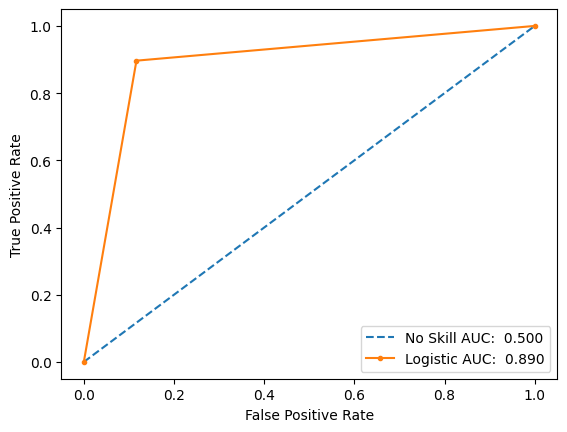

In [116]:
#Gráfico de la curva ROC
plt.plot(ns_fpr, ns_tpr, linestyle='--', label=f'No Skill AUC: {ns_auc: .3f}')
plt.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic AUC: {lr_auc: .3f}')
# Etiquetas de los ejes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Mostrar la leyenda
plt.legend()
# Mostrar el gráfico
plt.show()

### Curva Precisión Sensibilidad

In [117]:
from sklearn.metrics import PrecisionRecallDisplay

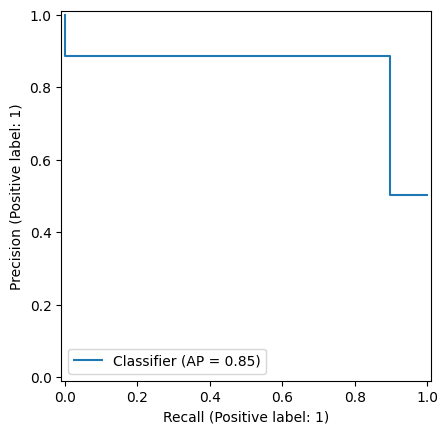

In [118]:
PrecisionRecallDisplay.from_predictions(y_val, y_pred);

In [119]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score

In [120]:
#Cálculo de las métricas recall y precisión
lr_precision, lr_recall, _ = precision_recall_curve(y_val, y_pred)
av_pre_score = round(average_precision_score(y_val, y_pred),3)
no_skill = len(y_val[y_val==1]) / len(y_val)


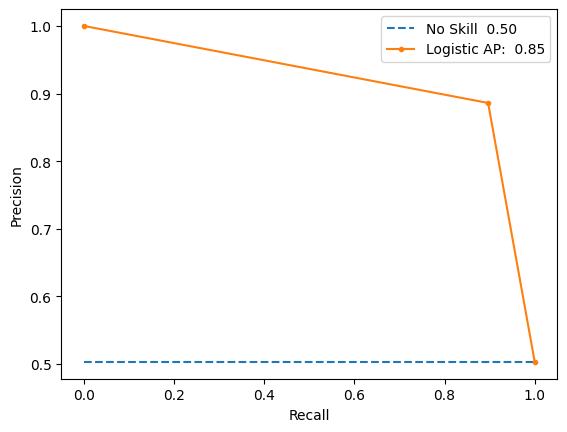

In [121]:
#Gŕafico de curva precision sensibilidad
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label=f'No Skill {no_skill: .2f}')
plt.plot(lr_recall, lr_precision, marker='.', label= f'Logistic AP: {av_pre_score: .2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.legend()

plt.show()


### Interpretación de las métricas y gráficos

En el gráfico ROC, observamos que el modelo tiene una excelente capacidad para distinguir entre las dos clases de churn, respaldado por un AUC de 0.89. Esto significa que el modelo es altamente eficaz separando a los clientes que se irán de los que se quedarán.

Otro aspecto crítico es la estabilidad del modelo: como se ve en la curva Precisión vs Sensibilidad (Recall), a medida que aumentamos la sensibilidad para capturar a más clientes en riesgo, la precisión no decae bruscamente, sino que se mantiene constante y en un valor muy alto, cercano al 90%.

En conclusión, el modelo logra un balance óptimo entre precisión y sensibilidad, permitiéndonos identificar al 90% de los desertores con un margen de error mínimo. Este rendimiento global se resume en el Puntaje Promedio de Precisión (AP) de 0.85, lo que garantiza una alta rentabilidad en las acciones de retención.

### **Evaluación del modelo de Regresión Logística con validación cruzada**

In [122]:
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_val_score, cross_validate

In [123]:
#Separamos las columnas predictoras y la que va a ser predecida
_X = df[model_cols]

_y = df['churned']

In [124]:
_X.columns

Index(['subscription_type', 'watch_hours', 'last_login_days', 'monthly_fee',
       'number_of_profiles', 'avg_watch_time_per_day', 'payment_method'],
      dtype='object')

In [125]:
#Instanciamos el modelo
regresion = LogisticRegression(random_state=42,  class_weight='balanced', max_iter=1000)


### **Crear el preprocesador**

In [126]:
#Preprocesador es la variable que contiene los pasos de preprocesamiento a seguir
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", RobustScaler(), numeric_cols)
    ],
    remainder= "passthrough"
)


### **Armar el pipeline**

In [ ]:
#Creamos el pipeline para el modelo de regresión logística
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model_regression", regresion)
])


In [158]:
#Creamos el objeto skfold que se encargará de la validación cruzada
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [159]:
cross_val_regresion = cross_validate(pipeline, _X, _y, cv=skfold, scoring=['precision','recall'])

In [160]:
cross_val_regresion

{'fit_time': array([0.01719046, 0.01803136, 0.0170126 , 0.01680183, 0.01672053]),
 'score_time': array([0.00963354, 0.00996685, 0.0091393 , 0.01098537, 0.00968099]),
 'test_precision': array([0.90873016, 0.90215264, 0.886     , 0.86740331, 0.90618762]),
 'test_recall': array([0.91053678, 0.91650099, 0.88071571, 0.93638171, 0.90258449])}

In [161]:
print(f'La media de la métrica precisión en la validación cruzada es\
      : {cross_val_regresion['test_precision'].mean()} ± {cross_val_regresion['test_precision'].std()}\
        ')

La media de la métrica precisión en la validación cruzada es      : 0.8940947480552908 ± 0.01551334982719133        


In [162]:
print(f'La media de la métrica sensibilidad en la validación cruzada es\
      : {cross_val_regresion['test_recall'].mean()} ± {cross_val_regresion['test_recall'].std()}\
        ')

La media de la métrica sensibilidad en la validación cruzada es      : 0.9093439363817097 ± 0.018160138762098172        


### **Prueba del modelo regresión logística con los datos de prueba**

In [133]:
y_prueba_pred = clf.predict(X_test)
print(classification_report(y_test, y_prueba_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90       497
           1       0.90      0.90      0.90       503

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



## Matriz de confusión

In [144]:
print(confusion_matrix(y_test, y_prueba_pred))

[[444  53]
 [ 49 454]]


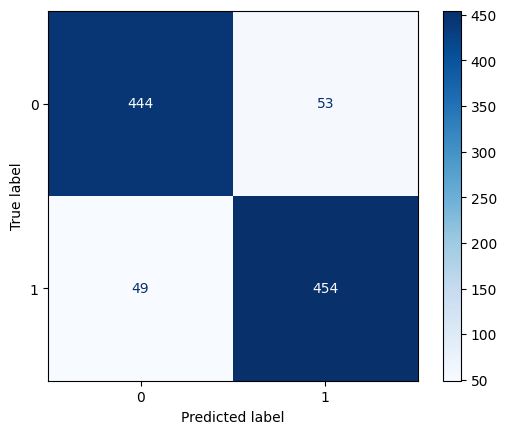

In [150]:
visualizacion = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_prueba_pred))
visualizacion.plot(cmap='Blues');

### Precisión

In [147]:
print(accuracy_score(y_test, y_prueba_pred))

0.898


### Curva ROC ambos modelos, comparando con uno sin habilidades

In [148]:
#Gráfico alternativo de la curva ROC
# Generar un predictor sin habilidad
ns_probs = [0 for _ in range(len(y_test))]

# Calculo de la métrica auc
#Predictor sin habilidad
ns_auc = roc_auc_score(y_test, ns_probs)
#Predictor Linear Regression
lr_auc = roc_auc_score(y_test, y_prueba_pred)
#Predictor Random Forest
#rf_auc = roc_auc_score(y_test, y_prueba_pred)

# Cáculo de la curva roc
ns_fpr, ns_tpr, t = roc_curve(y_test, ns_probs)
lr_fpr, lr_tpr, t = roc_curve(y_test, y_prueba_pred)
#rf_fpr, rf_tpr, t = roc_curve(y_test, y_pred_rf)

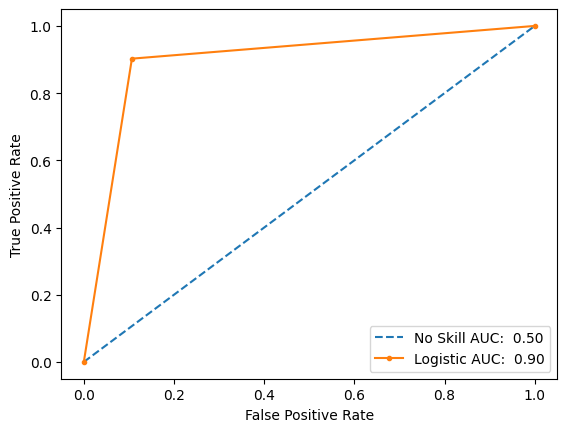

In [149]:

# Calculate rf_auc since it was not defined before
#rf_auc = roc_auc_score(y_test, y_pred_rf)
lr_auc = roc_auc_score(y_test, y_prueba_pred)

#Gráfico de la curva ROC
plt.plot(ns_fpr, ns_tpr, linestyle='--', label=f'No Skill AUC: {ns_auc: .2f}')
plt.plot(lr_fpr, lr_tpr, marker='.', label=f'Logistic AUC: {lr_auc: .2f}')
#plt.plot(rf_fpr,rf_tpr,marker='.',label=f'Random Forest AUC: {rf_auc: .2f}')

# Etiquetas de los ejes
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Mostrar la leyenda
plt.legend()
# Mostrar el gráfico
plt.show()

## En vista de que la precisión del modelo Random Forest es 0.99 se considera que el modelo hace "overfitting", por lo tanto se usará el model de Logistic Regression

## **Serializamos el modelo**

In [134]:
import pickle

with open('modelo.pkl', 'wb') as archivo:
    pickle.dump(clf, archivo)

## **Cargamos el modelo**


In [135]:
with open('modelo.pkl', 'rb') as archivo:
    clf = pickle.load(archivo)

## **Probabilidades / API**

In [136]:
#Probabilidad de que un cliente se vaya (churn=1)
y_proba = clf.predict_proba(X_test)[:, 1]
y_proba[:10]


array([2.05980831e-05, 9.67611161e-01, 8.09438268e-01, 9.84027039e-01,
       9.92796498e-01, 9.81732474e-01, 9.09949610e-01, 9.99943074e-01,
       3.27519238e-01, 7.48975483e-01])

In [137]:
def predict_cliente(input_dict):
    """
    Documentación de la función
    """
    #df con las caracteristicas del cliente a predecir
    df_input = pd.DataFrame([input_dict])
    #Guardamos la variable id
    id = int(df_input['customer_id'].iloc[0])
    #luego la eliminamos del df para que no intervenga en el modelo
    datos_input = df_input.drop(columns=['customer_id'])
    #corremos el modelo
    proba = clf.predict_proba(datos_input)[0, 1]
    pred = "Va a cancelar" if proba >= 0.5 else "Va a continuar"
    # la salida: id junto con la predicción del modelo
    return {
        "customer_id": id,
        "prediction": pred,
        "probability": round(float(proba), 3)
    }
    
    

## **Función de predicción**

### Probar con un cliente / Manual

In [138]:
cliente_ejemplo = {
    "customer_id": 10,
    "subscription_type": "Standard",
    "watch_hours": 3,
    "last_login_days": 1,
    "monthly_fee": 16,
    "number_of_profiles": 2,
    "avg_watch_time_per_day": 0.35,
    "payment_method": "Debit Card"

}

print(f'La predicción del modelo es:{predict_cliente(cliente_ejemplo)}')


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


ValueError: could not convert string to float: 'Standard'